In [12]:
import torch
import torch.nn.functional as F
from torch import nn
import torchvision
from torch.utils.data import Dataset
from torchvision import datasets, models, transforms
from torchsummary import summary

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import random
from shutil import copyfile
import xml.etree.ElementTree as ET
from PIL import Image
from copy import deepcopy
os.environ["CUDA_VISIBLE_DEVICES"]="0"

from utils import *
from custom_dataset import cub, imagenet

In [2]:
# model_name = 'vgg16' 
model_name = 'resnet50'
# dataset_name = 'cub'  
dataset_name = 'imagenet'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOG_DIR = 'logs'
ICP_DIR = 'icp'

log_model_data_path = os.path.join(LOG_DIR, '{}/{}'.format(model_name, 
                                                           dataset_name))
# train_log_path = os.path.join(log_model_data_path, '{}_{}_log.txt'.format(model_name,
#                                                                           dataset_name))

if dataset_name == 'cub':
    dataset_root = '/archive/workspace/datasets/CUB_200_2011'
    class_txt = os.path.join(dataset_root, 'classes.txt')
    data_dir = os.path.join(dataset_root, 'split')
    
    with open(class_txt, 'r') as f:
        lines = f.readlines()
    
    class_names = {}
    for line in lines:
        cls_idx = int(line.split(' ')[0])-1
        cls_name = line.split('.')[1].replace('\n', '')
        class_names[cls_idx] = cls_name
    nb_classes = len(class_names.keys())
    input_size = 224
    
    if model_name == 'vgg16':
        icp_path = os.path.join(ICP_DIR, 'icp_cub_3_5_7_11_14.npy')
    elif model_name == 'resnet50':
        icp_path = os.path.join(ICP_DIR, 'icp_cub_3_5_7.npy')
        
elif dataset_name == 'imagenet':
    data_dir = '/archive/workspace/datasets/ILSVRC2012'
    nb_classes = 1000
    input_size = 224
    
    if model_name == 'vgg16':
        icp_path = os.path.join(ICP_DIR, 'icp_image_4_5_7_11_14.npy')
    elif model_name == 'resnet50':
        icp_path = os.path.join(ICP_DIR, 'icp_imagenet_4_5_7.npy')
        
print('model_name: ', model_name)
print('dataset_name: ', dataset_name)
print("icp_path: ", icp_path)

model_name:  resnet50
dataset_name:  imagenet
icp_path:  icp/icp_imagenet_4_5_7.npy


In [3]:
if dataset_name == 'imagenet':
    if model_name == 'vgg16':
        model = torchvision.models.vgg16(pretrained='IMAGENET1K_V1')
    elif model_name == 'resnet50':
        model = torchvision.models.resnet50(pretrained='IMAGENET1K_V1')

else:
    print('load')
    model, input_size = load_trained_model(model_name, dataset_name, nb_classes)
    
    
model.eval()
model = model.to(device)
summary(model, (3, 224, 224))   

/archive/library/anaconda3/envs/xai/lib/python3.7/site-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/archive/library/anaconda3/envs/xai/lib/python3.7/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

## CUB

### Extract correct data

In [13]:
dataset_root = '/archive/workspace/datasets/'
cub_batch_size = 1

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cub_test_ds= cub.Cub2011(root=dataset_root, 
                         train=False,
                         transform=transform,
                         download=False)

cub_test_dl = torch.utils.data.DataLoader(cub_test_ds,
                                          batch_size=cub_batch_size, 
                                          shuffle=False, 
                                          num_workers=4)

In [15]:
from shutil import copyfile

base_dir = cub_test_ds.base_folder

val_correct_base_path = os.path.join(data_dir, 'val_correct_resnet')
if os.path.exists(val_correct_base_path) == False:
    os.mkdir(val_correct_base_path)
    
with torch.no_grad():
    for step, data in enumerate(cub_test_dl):
        x, y, _, path = data
        path = path[0]
        x = x.to(device)
        y = y.to(device)

        o = model(x)
        _, p = torch.max(o.data, 1)
        correct = (p == y).sum().item()
        
        if correct == 1:
            cls_name = path[len(base_dir):].split('/')[0]
            img_name = path[len(base_dir):].split('/')[1]

            val_correct_path = os.path.join(val_correct_base_path, cls_name)
            if os.path.exists(val_correct_path) == False:
                os.mkdir(val_correct_path)

            val_correct_img_path = os.path.join(val_correct_path, img_name)
            copyfile(path, val_correct_img_path)
 

# ImageNet

### Custom dataset

In [157]:
class ImageNet2012(Dataset):
    def __init__(self, root, train=True, transform=None):
        self.root = root
        self.transform = transform
        self.loader = default_loader
        self.train = train
        
        self.cls_json = os.path.join(self.root, 'imagenet_class_index.json')
        
        self.idx2label = []
        self.cls2label = {}
        self.cls2idx = {}
        self.label2cls = {}
        self.label2idx = {}
        
        self._get_metadata()
        
        self.classes, self.image_paths, self.image_labels = self._get_img_paths()
        self.bboxes = self._get_bbox_info()
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")
        bbox = self.bboxes[idx]
        label = self.image_labels[idx]

        w, h = image.width, image.height
        
        if self.transform:
            image = self.transform(image)

        _, rs_w, rs_h = image.shape
        
        bbox = self._get_resized_bbox(h, w, rs_h, rs_w, bbox)
        
        return image, label, bbox, path
    
    def get_item_with_name(self, name):
        idx = -1
        
        for i, path in enumerate(self.image_paths):
            if name in path: 
                idx = i
                break
                
        if idx == -1:
            print("Cannot find item for name")
            return None
        else:
            return self.__getitem__(i)
        
    def _get_bbox_info(self):
        bbox_dir = os.path.join(self.root, 'bbox')
        
        if self.train:
            bbox_dir = os.path.join(bbox_dir, 'train')
        else:
            bbox_dir = os.path.join(bbox_dir, 'val')
        
        bboxes = []
        
        for image_path in self.image_paths:
            iamge_name = image_path.split('/')[-1].split('.')[0]
            
            bbox_path = os.path.join(bbox_dir, '{}.xml'.format(iamge_name))
            
            tree = ET.parse(bbox_path)
            xml_root = tree.getroot()
            bndbox = xml_root.find('./object/bndbox')
            
            xmin = int(bndbox.find('xmin').text)
            ymin = int(bndbox.find('ymin').text)
            xmax = int(bndbox.find('xmax').text)
            ymax = int(bndbox.find('ymax').text)
            
            width = xmax-xmin
            height = ymax-ymin
            bboxes.append([xmin, ymin, width, height])
            
        return bboxes
    
    def _get_img_paths(self):
        if self.train:
            path = os.path.join(self.root, 'train')
        else:
            path = os.path.join(self.root, 'val')

        classes = list(self.cls2label.keys())
        
        paths = []
        labels = []
        for classs in classes:
            cls_path = os.path.join(path, classs)
            for img_name in os.listdir(cls_path):
                paths.append(os.path.join(cls_path, img_name))
                labels.append(self.cls2idx[classs])

        return classes, paths, labels
            
        
    def _get_metadata(self):
        class_idx = json.load(open(self.cls_json))
        
        self.idx2label = [class_idx[str(k)][1] for k in range(len(class_idx))]
        self.cls2label = {class_idx[str(k)][0]: class_idx[str(k)][1] for k in range(len(class_idx))}
        self.cls2idx = {class_idx[str(k)][0]: idx for k, idx in enumerate(class_idx.keys())}
        self.label2cls = {class_idx[str(k)][1]: class_idx[str(k)][0] for k, idx in enumerate(class_idx.keys())}
        self.label2idx = {class_idx[str(k)][1]: idx for k, idx in enumerate(class_idx.keys())}
           
    def get_label(self, idx=None, class_name=None):
        if idx == None and class_name == None:
            return None 
        elif idx != None:
            return self.idx2label[idx]
        else:
            return self.cls2label[class_name]
    
    def get_idx(self, class_name=None):
        if class_name == None:
            return None
        else:
            return int(self.cls2idx[class_name])
        
        
    def _get_resized_bbox(self, h, w, rs_h, rs_w, bbox):
        w_ratio, h_ratio = rs_w/w, rs_h/h
        bbox[0] = int(bbox[0]*w_ratio)
        bbox[1] = int(bbox[1]*h_ratio)
        bbox[2] = int(bbox[2]*w_ratio)
        bbox[3] = int(bbox[3]*h_ratio)
        
        return bbox

In [158]:
base_folder = '/archive/workspace/datasets/ILSVRC2012'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

ds = ImageNet2012(root=base_folder, train=False, transform=transform)

In [165]:
x, y, bbox, path = ds.__getitem__(22222)

7 21 201 190
bicycle-built-for-two
/archive/workspace/datasets/ILSVRC2012/val/n02835271/ILSVRC2012_val_00005274.JPEG


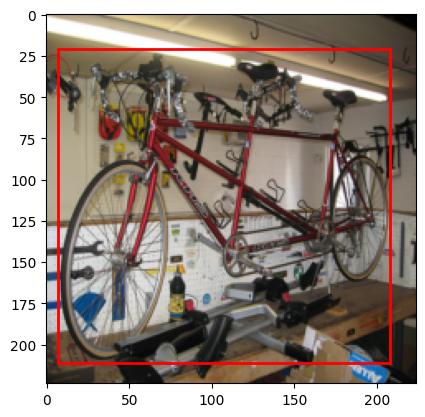

In [166]:
fig, ax = plt.subplots(1, 1)

print(bbox[0], bbox[1], bbox[2], bbox[3])
rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], 
                         linewidth=2, edgecolor='r', facecolor='none')

ax.add_patch(rect)
ax.imshow(x.permute(1,2,0).squeeze().clone().detach().cpu())
print(ds.get_label(idx=int(y)))
print(path)

In [141]:
ds.get_label(class_name='n02437616')

'llama'

### Extract coorect Imagenet 

In [5]:
root = '/archive/workspace/datasets/ILSVRC2012'

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


imgnet_ds = imagenet.ImageNet2012(root=root, train=False, transform=transform)


imgnet_dl = torch.utils.data.DataLoader(imgnet_ds,
                                        batch_size=1, 
                                        shuffle=False, 
                                        num_workers=4)

In [ ]:
from shutil import copyfile

base_dir = imgnet_ds.root

val_correct_base_path = os.path.join(data_dir, 'val_correct_resnet')
if os.path.exists(val_correct_base_path) == False:
    os.mkdir(val_correct_base_path)
    
print('val_correct_base_path: ', val_correct_base_path)
    
with torch.no_grad():
    for step, data in enumerate(imgnet_dl):
        x, y, _, path = data
        path = path[0]
        x = x.to(device)
        y = y.to(device)
        
        o = model(x)
        _, p = torch.max(o.data, 1)
        correct = (p == y).sum().item()
        
        if step%1000 == 0:
            print('step: ', step)
        
        if correct == 1:
            cls_name = path.split('/')[-2]
            img_name = path.split('/')[-1]
            
            val_correct_path = os.path.join(val_correct_base_path, cls_name)
            if os.path.exists(val_correct_path) == False:
                os.mkdir(val_correct_path)

            val_correct_img_path = os.path.join(val_correct_path, img_name)
            copyfile(path, val_correct_img_path)
 


### Imagenet cutting (10 images per class)

In [ ]:
import random

root = '/archive/workspace/datasets/ILSVRC2012'
nb_imgs_per_cls = 10

val_correct_resnet_dir = os.path.join(root, 'val_correct_resnet')

resnet_cls_list = os.listdir(val_correct_resnet_dir)
target = 'val_correct_resnet_10'
for cl in resnet_cls_list:
    path = os.path.join(val_correct_resnet_dir, cl)
    file_list = os.listdir(path)
    nb_files = len(file_list)
    
    new_path = os.path.join(root, target)
    new_path = os.path.join(new_path, cl)
    if os.path.exists(new_path) == False:
        os.mkdir(new_path)
    
    if nb_files > nb_imgs_per_cls:
        file_list = random.sample(file_list, nb_imgs_per_cls) 
        
    for img_name in file_list:
        orig_img_path = os.path.join(path, img_name)
        new_img_path = os.path.join(new_path, img_name)
        
        # copyfile(orig_img_path, new_img_path)

In [38]:
val_correct_vgg_dir = os.path.join(root, 'val_correct_vgg')

cls_list = os.listdir(val_correct_vgg_dir)
target = 'val_correct_vgg_10'
for cl in cls_list:
    path = os.path.join(val_correct_vgg_dir, cl)
    file_list = os.listdir(path)
    nb_files = len(file_list)
    
    new_path = os.path.join(root, target)
    new_path = os.path.join(new_path, cl)
    if os.path.exists(new_path) == False:
        os.mkdir(new_path)
    
    if nb_files > nb_imgs_per_cls:
        file_list = random.sample(file_list, nb_imgs_per_cls) 
        
    for img_name in file_list:
        orig_img_path = os.path.join(path, img_name)
        new_img_path = os.path.join(new_path, img_name)
        
        copyfile(orig_img_path, new_img_path)